# 02 — Limpeza, Padronização e Análise Exploratória
Neste notebook:
- Carregamos os dados brutos gerados no notebook 01
- Aplicamos limpeza e padronização
- Realizamos a análise exploratória inicial (EDA)
- Exportamos os dados processados para uso nos notebooks seguintes


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

df = pd.read_csv("../data/raw/vitimas.csv")
locais = pd.read_csv("../data/raw/locais.csv")
dosimetria = pd.read_csv("../data/raw/dosimetria.csv")

print("Shapes:", df.shape, locais.shape, dosimetria.shape)


Shapes: (249, 9) (7, 8) (57, 7)


## 2.1 — Inspeção Inicial

In [7]:
print("=== INFO ===")
print(df.info())
print("\n=== NULOS ===")
print(df.isnull().sum())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe())


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               249 non-null    int64  
 1   idade            249 non-null    int64  
 2   sexo             249 non-null    object 
 3   bairro           249 non-null    object 
 4   grupo_exposicao  249 non-null    object 
 5   dose_mSv         249 non-null    float64
 6   internado        249 non-null    int64  
 7   obito            249 non-null    int64  
 8   dias_desfecho    249 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 17.6+ KB
None

=== NULOS ===
id                 0
idade              0
sexo               0
bairro             0
grupo_exposicao    0
dose_mSv           0
internado          0
obito              0
dias_desfecho      0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===
               id       idade     dose_mSv   internado    

## 2.2 — Limpeza e Tipagem

In [8]:
# Padronizar categorias
df['grupo_exposicao'] = df['grupo_exposicao'].str.lower().str.strip()
df['sexo'] = df['sexo'].str.upper().str.strip()
df['bairro'] = df['bairro'].str.strip()

# Garantir tipos corretos
df['internado'] = df['internado'].astype(int)
df['obito'] = df['obito'].astype(int)
df['dose_mSv'] = df['dose_mSv'].astype(float)

# Criar faixas etárias
bins = [0, 12, 18, 30, 45, 60, 100]
labels = ['Criança (≤12)', 'Adolescente', 'Adulto jovem', 'Adulto', 'Meia-idade', 'Idoso']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels)

# Criar categorias de dose (mSv)
df['categoria_dose'] = pd.cut(
    df['dose_mSv'],
    bins=[0, 50, 200, 1000, 10001],
    labels=['< 50 mSv', '50–200 mSv', '200–1000 mSv', '> 1000 mSv']
)

print("✅ Limpeza concluída")
print(df['grupo_exposicao'].value_counts())
print(df['categoria_dose'].value_counts())


✅ Limpeza concluída
grupo_exposicao
leve        200
moderado     36
alto         13
Name: count, dtype: int64
categoria_dose
< 50 mSv        148
50–200 mSv       56
200–1000 mSv     31
> 1000 mSv       14
Name: count, dtype: int64


## 2.3 — Análise Exploratória

/home/itallo/Documentos/cesio137-analise/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/itallo/Documentos/cesio137-analise/venv/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


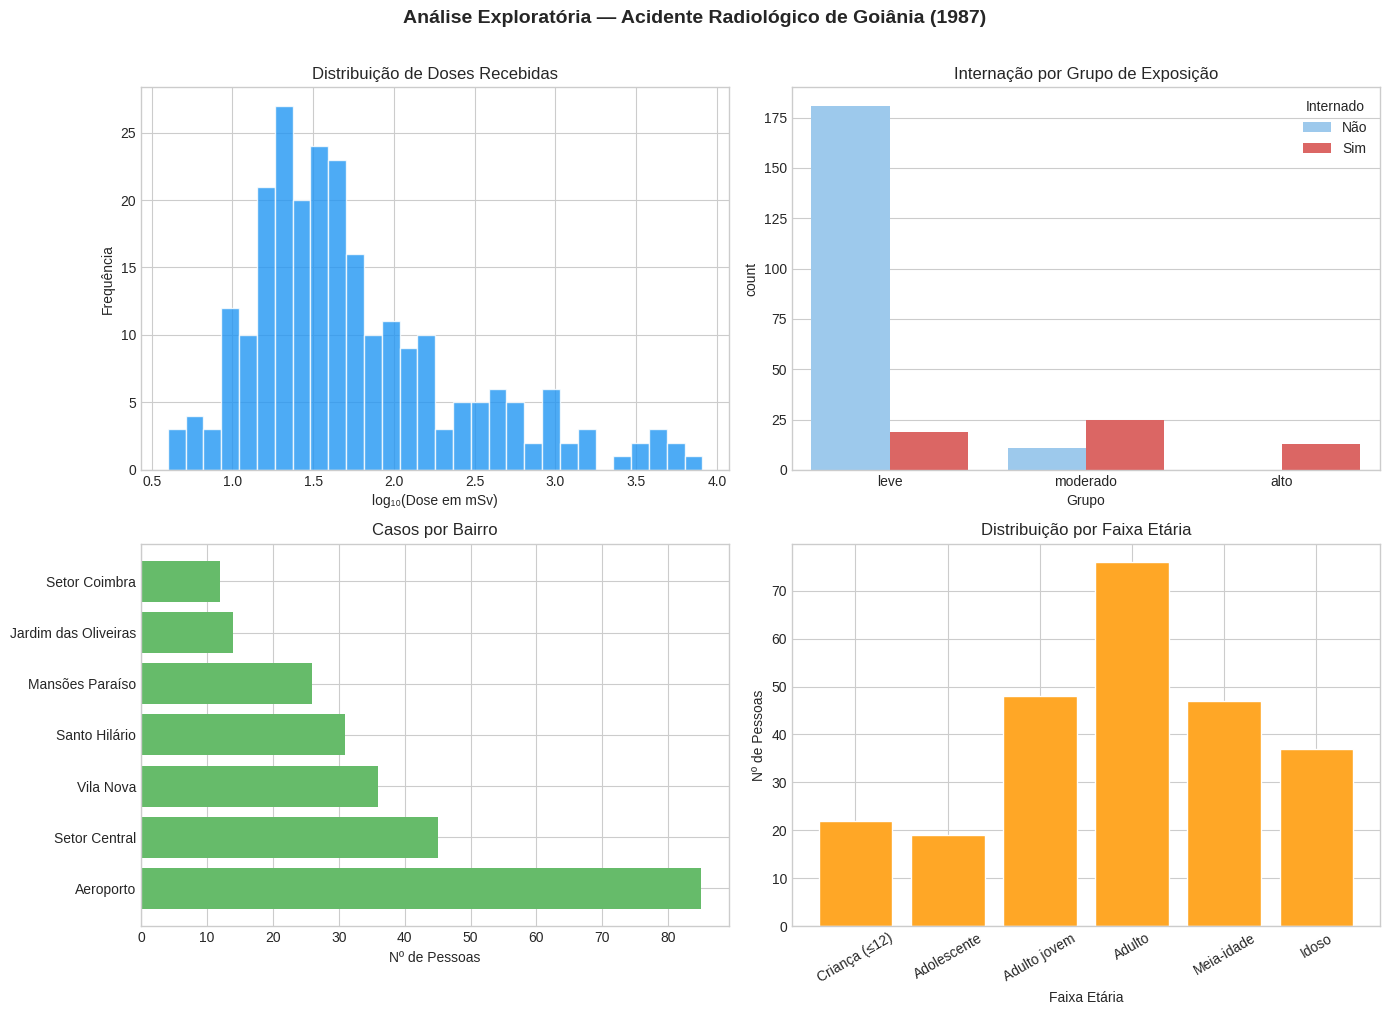

✅ Gráfico EDA salvo


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análise Exploratória — Acidente Radiológico de Goiânia (1987)", 
             fontsize=14, fontweight='bold', y=1.01)

# Distribuição de doses (escala log)
axes[0, 0].hist(np.log10(df['dose_mSv'] + 1), bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel("log₁₀(Dose em mSv)")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].set_title("Distribuição de Doses Recebidas")

# Internados por grupo
sns.countplot(data=df, x='grupo_exposicao', hue='internado', ax=axes[0, 1],
              order=['leve', 'moderado', 'alto'],
              palette={0: '#90CAF9', 1: '#EF5350'})
axes[0, 1].set_title("Internação por Grupo de Exposição")
axes[0, 1].set_xlabel("Grupo")
axes[0, 1].legend(title='Internado', labels=['Não', 'Sim'])

# Distribuição por bairro
bairro_counts = df['bairro'].value_counts()
axes[1, 0].barh(bairro_counts.index, bairro_counts.values, color='#66BB6A')
axes[1, 0].set_title("Casos por Bairro")
axes[1, 0].set_xlabel("Nº de Pessoas")

# Distribuição por faixa etária
faixa_counts = df['faixa_etaria'].value_counts().sort_index()
axes[1, 1].bar(faixa_counts.index.astype(str), faixa_counts.values, color='#FFA726', edgecolor='white')
axes[1, 1].set_title("Distribuição por Faixa Etária")
axes[1, 1].set_xlabel("Faixa Etária")
axes[1, 1].set_ylabel("Nº de Pessoas")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../reports/figures/02_eda_geral.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico EDA salvo")


## 2.4 — Exportar Dados Processados

In [10]:
df.to_csv("../data/processed/vitimas_clean.csv", index=False)
locais.to_csv("../data/processed/locais_clean.csv", index=False)
dosimetria.to_csv("../data/processed/dosimetria_clean.csv", index=False)

print("✅ Dados processados exportados para ../data/processed/")
print(f"   vitimas_clean.csv   — {len(df)} linhas, {df.shape[1]} colunas")
print(f"   locais_clean.csv    — {len(locais)} linhas")
print(f"   dosimetria_clean.csv — {len(dosimetria)} linhas")


✅ Dados processados exportados para ../data/processed/
   vitimas_clean.csv   — 249 linhas, 11 colunas
   locais_clean.csv    — 7 linhas
   dosimetria_clean.csv — 57 linhas
